#### Modules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, recall_score, balanced_accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from copy import deepcopy

#### Use GPU for calculation

Please use your GPU, do not wast your time on the stupid CPU

In [ ]:
# Select device - supports NVIDIA CUDA, Apple Metal (M-chips), or CPU fallback
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_type = "NVIDIA CUDA"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    device_type = "Apple Metal (M-chip)"
else:
    device = torch.device("cpu")
    device_type = "CPU"

print(f"Using device: {device} ({device_type})")

Using device: cuda (NVIDIA CUDA)


#### Train and testing splits 

Stratify ensures training, validation and testing datasets have the exact same proportion of crack and uncrack as the original dataset

In [ ]:
# Load datasets
df_walls = pd.read_pickle('wall_data.pkl')
df_decks = pd.read_pickle('deck_data.pkl')

# Split the Walls DataFrame (15% of total wall data for validation, hence 0.15 / 0.85 ≈ 0.176 for second split)
walls, walls_te = train_test_split(df_walls, test_size=0.2, random_state=42, stratify=df_walls['Label'])
walls_tr, walls_val = train_test_split(walls, test_size=0.176, random_state=42, stratify=walls['Label'])

# Split the Decks DataFrame
decks, decks_te = train_test_split(df_decks, test_size=0.2, random_state=42, stratify=df_decks['Label'])
decks_tr, decks_val = train_test_split(decks, test_size=0.176, random_state=42, stratify=decks['Label'])

#### CNN Architecture

The network consists of 4 convolution layers and 3 hidden layers to be trained. The filters extract features in the image and pass the filter data to the neural network to perform classification.

In [ ]:
class CNNBinary(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Adding padding=1 and BatchNorm2d
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Replaced Flatten with AdaptiveAvgPool2d
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Input is now just 256, drastically reducing parameters
            nn.Linear(256, 128), 
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)       # Global Average Pooling
        x = self.classifier(x)
        return x


class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = deepcopy(model.state_dict())
            return False

        self.counter += 1
        return self.counter >= self.patience

label_map = {'Non-Cracked': 0.0, 'Cracked': 1.0}

#### Data Generator (Memory Efficient)

Instead of loading all images into memory at once, which causes the RAM TO EXPLODE, use a generator that loads images in batches to RAM during training.

In [ ]:
# Custom PyTorch dataset (memory efficient)
class CrackDataset(Dataset):
    def __init__(self, dataframe, label_map):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = row['ImageData'].astype(np.float32) / 255.0
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)

        image = np.transpose(image, (2, 0, 1))
        x = torch.from_numpy(image)
        y = torch.tensor(self.label_map[row['Label']], dtype=torch.float32)

        return x, y

#### Training phase

1. Use adam as gradient decent computation

2. First train on training dataset to optimize the parameters in filters and hidden layers

3. The criterion_loss is the POS Loss Function computed earlier, which is distinct for each dataset

4. Next, use validation set to track the training process so that the model is not over trained on too much epoch.

5. The early stop is going to stop the training once F1 score of the model cease to decrease after 5 epoches (controlled using patience)

In [ ]:
model_walls = CNNBinary().to(device)
model_decks = CNNBinary().to(device)

optimizer_walls = optim.Adam(model_walls.parameters(), lr=1e-4)
optimizer_decks = optim.Adam(model_decks.parameters(), lr=1e-4)

def train_model(model, train_loader, val_loader, optimizer, criterion_loss, device, epochs=300, patience=5, scheduler=None):
    
    # Early stopping based on F1 score instead of loss
    early_stopper = EarlyStopping(patience=patience)
    history = {"train_loss": [], "train_acc": [], "train_f1": [],
               "val_loss": [], "val_acc": [], "val_f1": [], "lr": []}
    best_f1_val = 0.0
    
    # Training phase
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_train_preds = []
        all_train_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            # Compute loss function (logits is prediction probability, labels is ground truth) 
            optimizer.zero_grad()
            logits = model(images).squeeze(1)
            loss = criterion_loss(logits, labels)
            # Gradient backpropagation and optimization step
            loss.backward()
            # For MPS backend on Apple Silicon, use synchronize to ensure proper gradient updates
            if device.type == "mps":
                torch.mps.synchronize()
            # Use predicted probability (logits) to calculate training loss
            optimizer.step()
            running_loss += loss.item() * labels.size(0)
            # Use threshold of 0.5 to determine predicted class
            preds = (torch.sigmoid(logits) >= 0.5).float()
            # Predicted label compared to truth label for accuracy calculation
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            # Store predictions and labels for metrics calculation
            all_train_preds.extend(preds.detach().cpu().numpy())
            all_train_labels.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / total
        train_acc = correct / total
        train_f1 = f1_score(all_train_labels, all_train_preds, zero_division=0)
        train_recall = recall_score(all_train_labels, all_train_preds, zero_division=0)

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                # Use probability to calculate training loss (logits) and use threshold of 0.5 to determine predicted class
                logits = model(images).squeeze(1)
                loss = criterion_loss(logits, labels)
                # Assign prediction label based on predicted probability (logits) and threshold
                val_running_loss += loss.item() * labels.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                # Store predictions and labels for metrics calculation
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        # Calculate training validation metrics (loss, accuracy, F1 score)
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_val_labels, all_val_preds, zero_division=0)
        val_recall = recall_score(all_val_labels, all_val_preds, zero_division=0)
        
        if scheduler is not None:
            # ReduceLROnPlateau expects a monitored metric
            scheduler.step(val_f1)

        current_lr = optimizer.param_groups[0]['lr']
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["lr"].append(current_lr)
        print(f"Epoch {epoch+1}/{epochs} - "
              f"train_loss: {train_loss:.4f}, train_f1: {train_f1:.4f}, train_recall:{train_recall:.4f} | "
              f"val_loss: {val_loss:.4f}, val_f1: {val_f1:.4f}, val_recall:{val_recall:.4f} | "
              f"lr: {current_lr:.6f}")

        # Early stopping based on F1 score
        if val_f1 > best_f1_val:
            best_f1_val = val_f1
            early_stopper.best_state = deepcopy(model.state_dict())
            early_stopper.counter = 0
        else:
            early_stopper.counter += 1
            if early_stopper.counter >= patience:
                print("Early stopping triggered (F1 score not improving).")
                break
        
    if early_stopper.best_state is not None:
        model.load_state_dict(early_stopper.best_state)

    return history

#### POS weight for loss function

This is the weight assigned to each class in the loss function so that the penality for wrong prediction of minor class is more heavily penalize in the loss function. The value depends on the ratio between majority and minority

In [ ]:
def calculate_pos_weight(dataframe, label_map):
    labels = dataframe['Label'].map(label_map).values
    num_neg = (labels == 0).sum()
    num_pos = (labels == 1).sum()
    if num_pos == 0:
        return torch.tensor(1.0)
    pos_weight = num_neg / num_pos
    return torch.tensor(pos_weight, dtype=torch.float32)

In [ ]:
# Create data loaders for Walls dataset (memory efficient)
train_ds_walls = CrackDataset(walls_tr, label_map)
val_ds_walls = CrackDataset(walls_val, label_map)
test_ds_walls = CrackDataset(walls_te, label_map)

# pos_weight for Walls training set
pos_weight_walls = calculate_pos_weight(walls_tr, label_map)
criterion_bce_weighted_walls = nn.BCEWithLogitsLoss(pos_weight=pos_weight_walls.to(device))
print(f"Walls pos_weight: {pos_weight_walls.item():.4f}")

# pin_memory optimization is specific to NVIDIA CUDA (not applicable to MPS or CPU)
pin_memory = torch.cuda.is_available()
train_loader_walls = DataLoader(train_ds_walls, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader_walls = DataLoader(val_ds_walls, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_walls = DataLoader(test_ds_walls, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

Walls pos_weight: 3.7816


In [ ]:
# Create data loaders for Decks dataset (memory efficient)
train_ds_decks = CrackDataset(decks_tr, label_map)
val_ds_decks = CrackDataset(decks_val, label_map)
test_ds_decks = CrackDataset(decks_te, label_map)

# pos_weight for Decks training set
pos_weight_decks = calculate_pos_weight(decks_tr, label_map)
criterion_bce_weighted_decks = nn.BCEWithLogitsLoss(pos_weight=pos_weight_decks.to(device))
print(f"Decks pos_weight: {pos_weight_decks.item():.4f}")

# pin_memory optimization is specific to NVIDIA CUDA (not applicable to MPS or CPU)
pin_memory = torch.cuda.is_available()
train_loader_decks = DataLoader(train_ds_decks, batch_size=32, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader_decks = DataLoader(val_ds_decks, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader_decks = DataLoader(test_ds_decks, batch_size=32, shuffle=False, num_workers=0, pin_memory=pin_memory)

Decks pos_weight: 5.9661


In [ ]:
print("Wall ModelTraining with Weighted Loss (BCE with pos_weight)...\n")
scheduler_walls = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_walls, mode='max', factor=0.5, patience=2, min_lr=1e-6)

history_walls = train_model(
    model_walls,
    train_loader_walls,
    val_loader_walls,
    optimizer_walls,
    criterion_bce_weighted_walls,
    device,
    epochs=300,
    patience=5,
    scheduler=scheduler_walls)

Wall ModelTraining with Weighted Loss (BCE with pos_weight)...

Epoch 1/300 - train_loss: 1.0597, train_f1: 0.3871, train_recall:0.7436 | val_loss: 1.0312, val_f1: 0.3988, val_recall:0.7405 | lr: 0.000100
Epoch 2/300 - train_loss: 1.0237, train_f1: 0.4187, train_recall:0.6636 | val_loss: 1.0015, val_f1: 0.4195, val_recall:0.7424 | lr: 0.000100
Epoch 3/300 - train_loss: 0.9894, train_f1: 0.4434, train_recall:0.6789 | val_loss: 0.9619, val_f1: 0.4501, val_recall:0.6875 | lr: 0.000100
Epoch 4/300 - train_loss: 0.9620, train_f1: 0.4594, train_recall:0.6826 | val_loss: 0.9856, val_f1: 0.4497, val_recall:0.3598 | lr: 0.000100
Epoch 5/300 - train_loss: 0.9375, train_f1: 0.4729, train_recall:0.6947 | val_loss: 0.9098, val_f1: 0.4570, val_recall:0.7595 | lr: 0.000100
Epoch 6/300 - train_loss: 0.9076, train_f1: 0.4892, train_recall:0.6826 | val_loss: 0.9008, val_f1: 0.5197, val_recall:0.6250 | lr: 0.000100
Epoch 7/300 - train_loss: 0.8796, train_f1: 0.5113, train_recall:0.6842 | val_loss: 0.9137

In [ ]:
print("Deck ModelTraining with Weighted Loss (BCE with pos_weight)...\n")
scheduler_decks = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_decks, mode='max', factor=0.5, patience=2, min_lr=1e-6)

history_decks = train_model(
    model_decks,
    train_loader_decks,
    val_loader_decks,
    optimizer_decks,
    criterion_bce_weighted_decks,
    device,
    epochs=300,
    patience=5,
    scheduler=scheduler_decks)

Deck ModelTraining with Weighted Loss (BCE with pos_weight)...

Epoch 1/300 - train_loss: 1.1648, train_f1: 0.2739, train_recall:0.8126 | val_loss: 1.1280, val_f1: 0.3163, val_recall:0.6863 | lr: 0.000100
Epoch 2/300 - train_loss: 1.1272, train_f1: 0.3119, train_recall:0.6693 | val_loss: 1.1994, val_f1: 0.2665, val_recall:0.9594 | lr: 0.000100
Epoch 3/300 - train_loss: 1.1022, train_f1: 0.3285, train_recall:0.6512 | val_loss: 1.0849, val_f1: 0.3922, val_recall:0.4465 | lr: 0.000100
Epoch 4/300 - train_loss: 1.0796, train_f1: 0.3417, train_recall:0.6386 | val_loss: 1.0740, val_f1: 0.4015, val_recall:0.3838 | lr: 0.000100
Epoch 5/300 - train_loss: 1.0504, train_f1: 0.3688, train_recall:0.6394 | val_loss: 1.3314, val_f1: 0.2790, val_recall:0.9446 | lr: 0.000100
Epoch 6/300 - train_loss: 1.0322, train_f1: 0.3783, train_recall:0.6559 | val_loss: 1.0172, val_f1: 0.3860, val_recall:0.7122 | lr: 0.000100
Epoch 7/300 - train_loss: 1.0151, train_f1: 0.3846, train_recall:0.6417 | val_loss: 1.0335

#### Evaluation Metrics - Recall, Precision, Confusion Matrix

Test Set Evaluation - Walls Dataset

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.92      0.92      0.92      2838
     Cracked       0.69      0.69      0.69       750

    accuracy                           0.87      3588
   macro avg       0.80      0.80      0.80      3588
weighted avg       0.87      0.87      0.87      3588



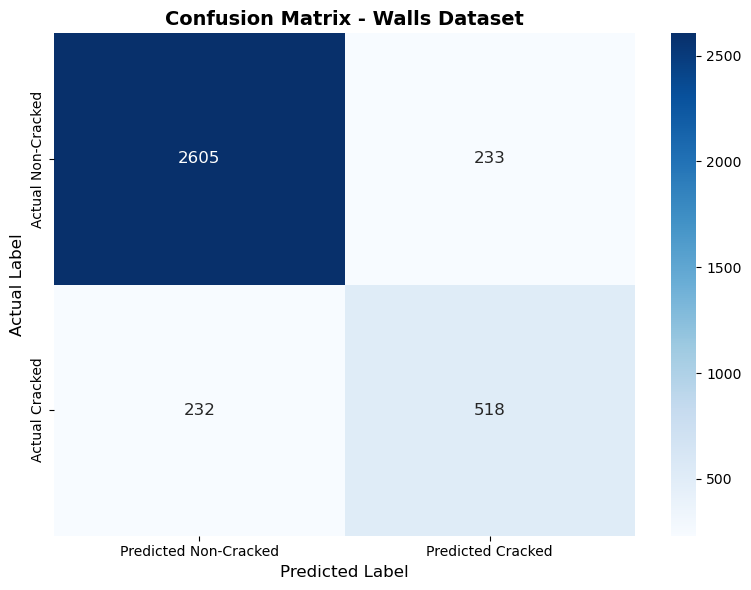

Test Set Evaluation - Decks Dataset

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.92      0.90      0.91      2300
     Cracked       0.48      0.52      0.50       385

    accuracy                           0.85      2685
   macro avg       0.70      0.71      0.71      2685
weighted avg       0.86      0.85      0.85      2685



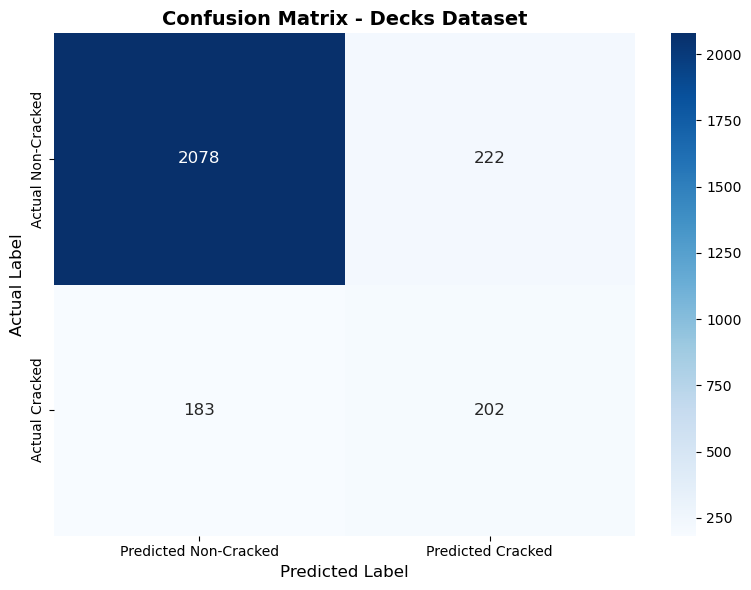

In [ ]:
# Function to evaluate model on test set and compute metrics (recall, precision, confusion matrix)
def evaluate_model(model, test_loader, device, threshold=0.5, dataset_name=""):
    # Evaluate model and compute recall, precision, confusion matrix
    model.eval()
    all_preds = []
    all_labels = []
    # Same logic as before to find the predicted label and acutal label
    # Use threshold to determine predicted class (0.5 is default for binary classification)
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images).squeeze(1)
            preds = (torch.sigmoid(logits) >= threshold).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Compute confusion matrix and show classification report (precision, recall, F1-score and etc)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=['Non-Cracked', 'Cracked'],output_dict=True)
    print(f"Test Set Evaluation - {dataset_name}")
    print(f"\nClassification Report:\n{classification_report(all_labels, all_preds, target_names=['Non-Cracked', 'Cracked'])}")
    
    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=['Predicted Non-Cracked', 'Predicted Cracked'],
                yticklabels=['Actual Non-Cracked', 'Actual Cracked'],
                annot_kws={'size': 12})
    plt.title(f'Confusion Matrix - {dataset_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    return cm, report, all_preds, all_labels


# Evaluate both models on test sets(use threshold of 0.5 for initial evaluation)
cm_walls, report_walls, preds_walls, labels_walls = evaluate_model(model_walls, test_loader_walls, device, threshold=0.5, dataset_name="Walls Dataset")
cm_decks, report_decks, preds_decks, labels_decks = evaluate_model(model_decks, test_loader_decks, device, threshold=0.5, dataset_name="Decks Dataset")

#### Threshold selction

Select the threshold the maximize certain metric (F1 score or recall)

In [ ]:
# Function to optimize threshold based on validation set performance (F1 score or recall)
def optimize_threshold(model, val_loader, device, metric='f1'):
    
    # The same logic as before to find out predicted label and true label on validation set
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images).squeeze(1)
            all_logits.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_logits = np.array(all_logits)
    all_labels = np.array(all_labels)
    
    # Iterate through different thresholds to find the one that maximizes the specified metric (F1 score or recall)
    best_threshold = 0.5
    best_score = 0.0
    threshold_scores = []
    # Try different thresholds based on metric (F1 score or recall) and store the scores for each threshold
    for threshold in np.arange(0.1, 0.9, 0.01):
        preds = (all_logits >= threshold).astype(int)
        if metric == 'f1':
            score = f1_score(all_labels, preds, zero_division=0)
        elif metric == 'recall':
            score = recall_score(all_labels, preds, zero_division=0)
        threshold_scores.append((threshold, score))
        # Find the best threshold based that maximizes the specified metric
        if score > best_score:
            best_score = score
            best_threshold = threshold
    return best_threshold, best_score, threshold_scores


# Find optimal thresholds for both models (using validation set to avoid data leakage)
best_threshold_walls, best_f1_walls, scores_walls = optimize_threshold(
    model_walls, val_loader_walls, device, metric='recall')

best_threshold_decks, best_f1_decks, scores_decks = optimize_threshold(
    model_decks, val_loader_decks, device, metric='recall')

print(f"\nWalls Model - Best Threshold (F1): {best_threshold_walls:.3f} (F1 score: {best_f1_walls:.4f})")
print(f"Decks Model - Best Threshold (F1): {best_threshold_decks:.3f} (F1 score: {best_f1_decks:.4f})")


Walls Model - Best Threshold (F1): 0.100 (F1 score: 0.9943)
Decks Model - Best Threshold (F1): 0.100 (F1 score: 0.9889)


#### Re-evaluate model performance on optimzied threshold

Test Set Evaluation - Walls Dataset

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.98      0.09      0.17      2838
     Cracked       0.22      0.99      0.37       750

    accuracy                           0.28      3588
   macro avg       0.60      0.54      0.27      3588
weighted avg       0.83      0.28      0.21      3588



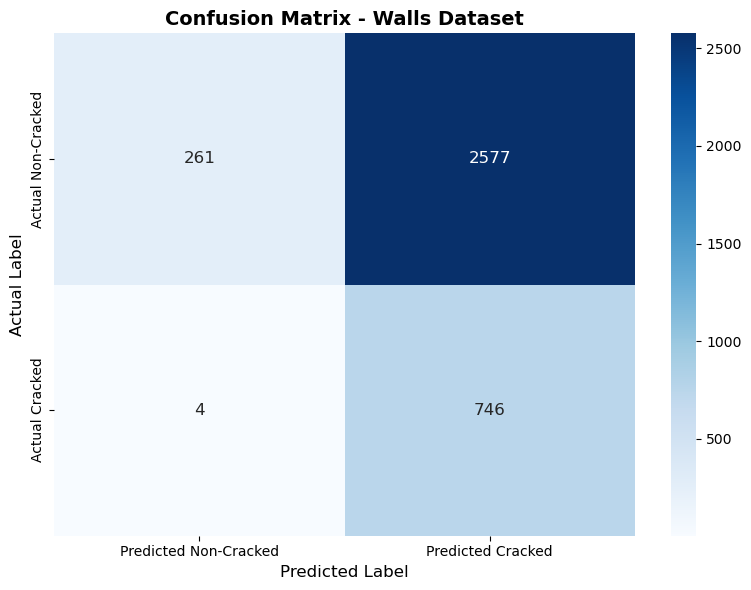

Test Set Evaluation - Decks Dataset

Classification Report:
              precision    recall  f1-score   support

 Non-Cracked       0.99      0.05      0.10      2300
     Cracked       0.15      1.00      0.26       385

    accuracy                           0.19      2685
   macro avg       0.57      0.52      0.18      2685
weighted avg       0.87      0.19      0.12      2685



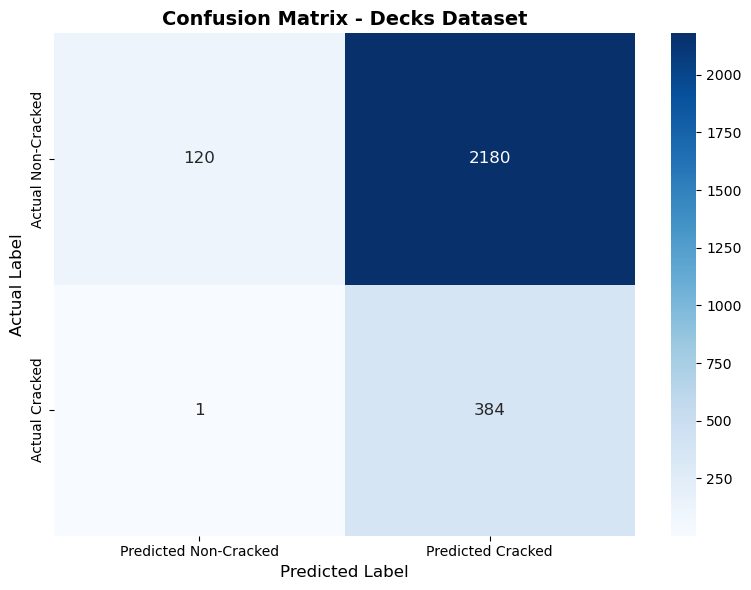

In [ ]:
# Evaluate both models on test sets using optimal thresholds
cm_walls_opt, report_walls_opt, preds_walls_opt, labels_walls_opt = evaluate_model(
    model_walls, test_loader_walls, device, threshold=best_threshold_walls, dataset_name="Walls Dataset")

cm_decks_opt, report_decks_opt, preds_decks_opt, labels_decks_opt = evaluate_model(
    model_decks, test_loader_decks, device, threshold=best_threshold_decks, dataset_name="Decks Dataset")

#### Save models and metadata for phase 3, finding out shit images from dataset

In [ ]:
# Save the trained models
torch.save(model_walls.state_dict(), 'model_walls.pth')
torch.save(model_decks.state_dict(), 'model_decks.pth')

# Save the best thresholds and metadata
import json
metadata = {'best_threshold_walls': float(best_threshold_walls),
            'best_threshold_decks': float(best_threshold_decks),
            'best_f1_walls': float(best_f1_walls),
            'best_f1_decks': float(best_f1_decks),
            'device_type': device_type}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)